In [1]:
# Install (if needed)
!pip install torch torchvision seaborn scikit-learn

# Imports
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
from sklearn.metrics import confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [2]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, transform=transform, download=True)

test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, transform=transform)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=64, shuffle=True)

test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=64)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 58.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.72MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.61MB/s]

Train size: 60000
Test size: 10000


# Define All Models

In [3]:
# 1. RNN
class RNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(28, 128, batch_first=True)
        self.fc = nn.Linear(128, 10)

    def forward(self, x):
        x = x.squeeze(1)
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])


# 2. LSTM
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(28, 128, batch_first=True)
        self.fc = nn.Linear(128, 10)

    def forward(self, x):
        x = x.squeeze(1)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


# 3. GRU
class GRUModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(28, 128, batch_first=True)
        self.fc = nn.Linear(128, 10)

    def forward(self, x):
        x = x.squeeze(1)
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])


# 4. BiLSTM
class BiLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(28, 128, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(256, 10)

    def forward(self, x):
        x = x.squeeze(1)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


# 5. CNN + LSTM
class CNN_LSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1,16,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.lstm = nn.LSTM(14,128,batch_first=True)
        self.fc = nn.Linear(128,10)

    def forward(self, x):
        x = self.cnn(x)
        x = x.mean(dim=1)
        out,_ = self.lstm(x)
        return self.fc(out[:,-1,:])

# Train Function (+ Gradient Analysis)

In [4]:
def train_model(model, epochs=3):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    losses = []

    for epoch in range(epochs):
        total_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()

            # Gradient tracking (for report)
            grad_list = []
            for name, param in model.named_parameters():
                if param.grad is not None:
                    grad_list.append(param.grad.abs().mean().item())

            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        losses.append(avg_loss)

        print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

    return losses

# Evaluation Function

In [5]:
def evaluate_model(model):
    model.eval()
    correct = 0
    total = 0
    preds, trues = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            preds.extend(predicted.cpu().numpy())
            trues.extend(labels.cpu().numpy())

    acc = 100 * correct / total
    return acc, preds, trues

# Train All Models

In [6]:
models = {
    "RNN": RNNModel(),
    "LSTM": LSTMModel(),
    "GRU": GRUModel(),
    "BiLSTM": BiLSTM(),
    "CNN+LSTM": CNN_LSTM()
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    start = time.time()

    loss = train_model(model)
    acc, preds, trues = evaluate_model(model)

    end = time.time()

    results[name] = {
        "loss": loss,
        "accuracy": acc,
        "time": end - start,
        "preds": preds,
        "trues": trues
    }

    print(f"{name} → Accuracy: {acc:.2f}%, Time: {end-start:.2f}s")


Training RNN...
Epoch 1, Loss: 0.7009
Epoch 2, Loss: 0.3180
Epoch 3, Loss: 0.2330
RNN → Accuracy: 94.00%, Time: 61.72s

Training LSTM...
Epoch 1, Loss: 0.5233
Epoch 2, Loss: 0.1583
Epoch 3, Loss: 0.1019
LSTM → Accuracy: 97.60%, Time: 131.13s

Training GRU...
Epoch 1, Loss: 0.5328
Epoch 2, Loss: 0.1391
Epoch 3, Loss: 0.0899
GRU → Accuracy: 97.26%, Time: 115.73s

Training BiLSTM...
Epoch 1, Loss: 0.4938
Epoch 2, Loss: 0.1467
Epoch 3, Loss: 0.1021
BiLSTM → Accuracy: 96.55%, Time: 261.85s

Training CNN+LSTM...
Epoch 1, Loss: 0.6535
Epoch 2, Loss: 0.1660
Epoch 3, Loss: 0.1081
CNN+LSTM → Accuracy: 96.92%, Time: 117.95s


# Loss Graph

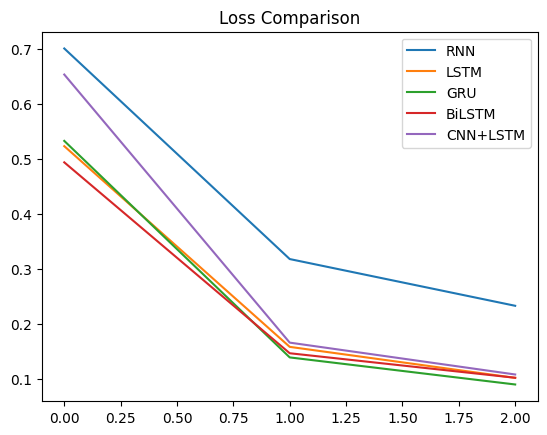

In [7]:
for name in results:
    plt.plot(results[name]["loss"], label=name)

plt.title("Loss Comparison")
plt.legend()
plt.show()

# Accuracy Bar Chart

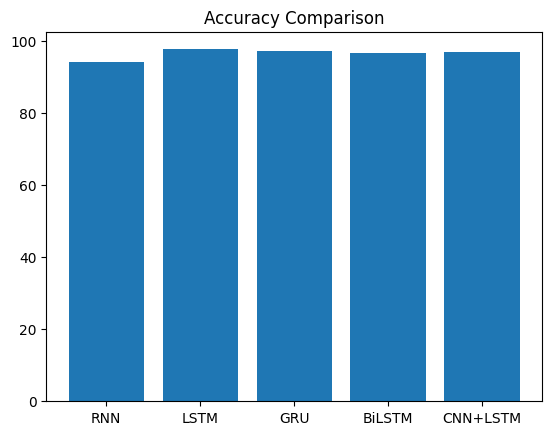

In [8]:
names = list(results.keys())
accs = [results[n]["accuracy"] for n in names]

plt.bar(names, accs)
plt.title("Accuracy Comparison")
plt.show()

# Confusion Matrix (Best Model)

Best Model: LSTM


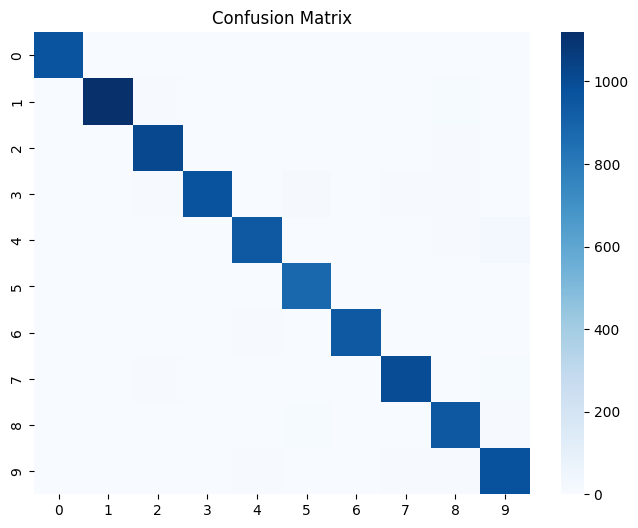

In [9]:
best_model_name = max(results, key=lambda x: results[x]["accuracy"])
print("Best Model:", best_model_name)

preds = results[best_model_name]["preds"]
trues = results[best_model_name]["trues"]

cm = confusion_matrix(trues, preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()